# Kelmarsh (UK): PECD capacity factor translated to MW vs. real metered generation

Every other PECD validation page in this book checks PECD against SMARD's
*national* aggregate. This one checks it against a single named wind
farm's own real metered generation: Kelmarsh, UK (6x Senvion MM92,
12.3 MW installed), whose operator (Cubico Sustainable Investments)
publishes its 10-minute grid-meter export on Zenodo (record 5841834,
CC-BY-4.0) -- `kelmarsh_grid_meter` / `kelmarsh_wt_static` in this hub.

Kelmarsh's coordinates (52.40°N, 0.94°W, Northamptonshire) fall in PECD
onshore wind zone **UK03** (the English Midlands zone) -- determined by
nearest-grid-cell lookup against `peon_region_mask.nc`; that cell is
~70% UK03 / ~30% UK01, close enough to a clean UK03 assignment for this
first pass.

Deliberately **not** comparing capacity factors directly: PECD's
capacity factor is translated into MW using Kelmarsh's own installed
capacity, so both series land on the same physical axis (MW) that can be
read directly against Kelmarsh's nameplate output. Prototyped in
`energy-research`'s exploratory pipeline before being rebuilt here
against this hub's own outputs -- see that repo's PROJECT.md for the
original investigation (identifying the pre-commissioning period and a
real October 2018 outage as the two biggest monthly mismatches).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from insights.paths import hub_file

PECD_ZONE = "UK03"

## Load Kelmarsh's static specs (installed capacity) and grid meter data

In [2]:
wt_static = pd.read_parquet(hub_file("kelmarsh", "kelmarsh_wt_static.parquet"))
installed_capacity_mw = wt_static["Rated power (kW)"].sum() / 1000
print(f"Installed capacity: {installed_capacity_mw} MW across {len(wt_static)} turbines")

grid = pd.read_parquet(hub_file("kelmarsh", "kelmarsh_grid_meter.parquet"))
grid.index = grid.index.tz_localize("UTC")

Installed capacity: 12.3 MW across 6 turbines


## Kelmarsh: 10-minute energy export -> hourly MW, plus hourly availability

Summing six consecutive 10-minute `Grid Meter Energy Export (kWh)`
readings gives the energy delivered in that hour (kWh) -- numerically
the same as the average power over that hour in kW, since the interval
is exactly 1 hour -- divide by 1000 for MW.

`Energy meter based availability` is a binary (0/1) flag per 10-minute
interval, at the whole-farm grid-meter level (tautological with
`Export > 0`, not an independent per-turbine status signal -- see
`energy-research`'s PROJECT.md). Averaged over an hour, the fraction of
the hour flagged available becomes a real downtime signal for hours
where PECD implies there *should* have been output.

In [3]:
kelmarsh_hourly_mw = (
    grid["Grid Meter Energy Export (kWh)"]
    .resample("h")
    .sum(min_count=6)
    .div(1000)
    .rename("kelmarsh_actual_mw")
)
hourly_availability = (
    grid["Energy meter based availability"].resample("h").mean().rename("hourly_availability")
)

## PECD onshore wind capacity factor for zone UK03, scaled to MW

In [4]:
pecd_decades = ["2010-2019", "2020-2025"]  # covers Kelmarsh's full 2016-2021 reporting window
pecd_cf = pd.concat(
    [
        pd.read_parquet(
            hub_file("pecd", "capacity_factors_europe", f"pecd_wind_onshore_tech30_{label}.parquet"),
            columns=[PECD_ZONE],
        )[PECD_ZONE]
        for label in pecd_decades
    ]
).sort_index()
pecd_cf.index = pecd_cf.index.tz_localize("UTC")

pecd_implied_mw = (pecd_cf * installed_capacity_mw).rename("pecd_implied_mw")

## Align to Kelmarsh's actual reporting window, and availability-adjust PECD

In [5]:
comparison = pd.concat([kelmarsh_hourly_mw, pecd_implied_mw, hourly_availability], axis=1, sort=True)
valid_range = kelmarsh_hourly_mw.dropna()
comparison = comparison.loc[valid_range.index.min() : valid_range.index.max()]
comparison["pecd_implied_mw_availability_adjusted"] = (
    comparison["pecd_implied_mw"] * comparison["hourly_availability"]
)

print(comparison.describe())

       kelmarsh_actual_mw  pecd_implied_mw  hourly_availability  \
count        30431.000000     31920.000000         30432.000000   
mean             3.299108         3.188471             0.904747   
std              3.269994         2.882649             0.283392   
min              0.000000         0.002460             0.000000   
25%              0.685550         0.822870             1.000000   
50%              2.208950         2.225070             1.000000   
75%              5.013300         4.932300             1.000000   
max             12.301500        11.044170             1.000000   

       pecd_implied_mw_availability_adjusted  
count                           30432.000000  
mean                                3.039326  
std                                 2.925584  
min                                 0.000000  
25%                                 0.632220  
50%                                 2.052870  
75%                                 4.811760  
max                 

## Daily-mean overlay

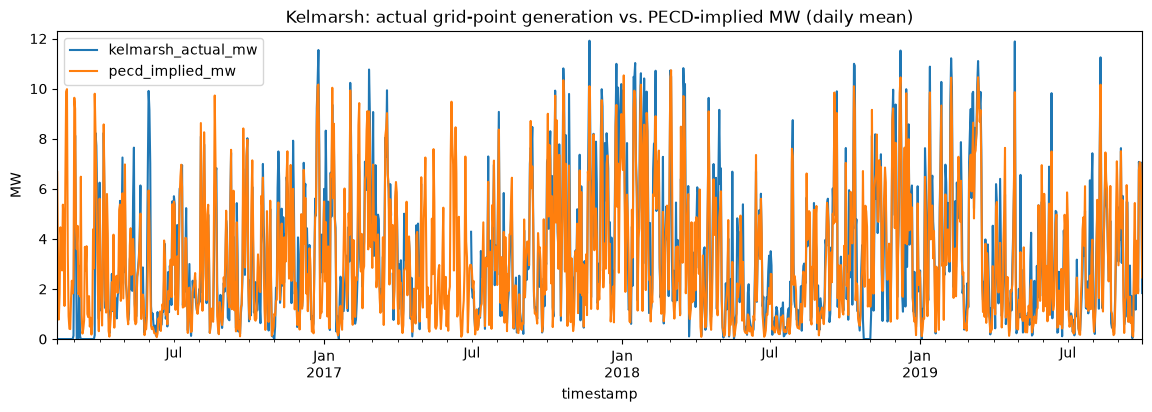

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
comparison[["kelmarsh_actual_mw", "pecd_implied_mw"]].resample("D").mean().plot(ax=ax)
ax.set_ylabel("MW")
ax.set_ylim(0, installed_capacity_mw)
ax.set_title("Kelmarsh: actual grid-point generation vs. PECD-implied MW (daily mean)")
plt.show()

The two clear troughs on the actual-generation line that PECD doesn't
share -- early 2016 and October 2018 -- aren't PECD errors: the
turbines' commercial operations date is 2016-04-15 (before that, the
farm wasn't yet fully generating), and October 2018's hourly
availability drops to its third-lowest value of the entire record
(67%, vs. a typical month's ~94%), consistent with a real outage or
maintenance event.

## Weekly availability over time

`hourly_availability` resampled to a weekly mean -- not the raw
10-minute flag, which is too noisy hour-to-hour to read as a trend.
This is where the pre-commissioning period and the October 2018 outage
actually show up as availability, rather than just being inferred from
the generation-vs-PECD gap above.

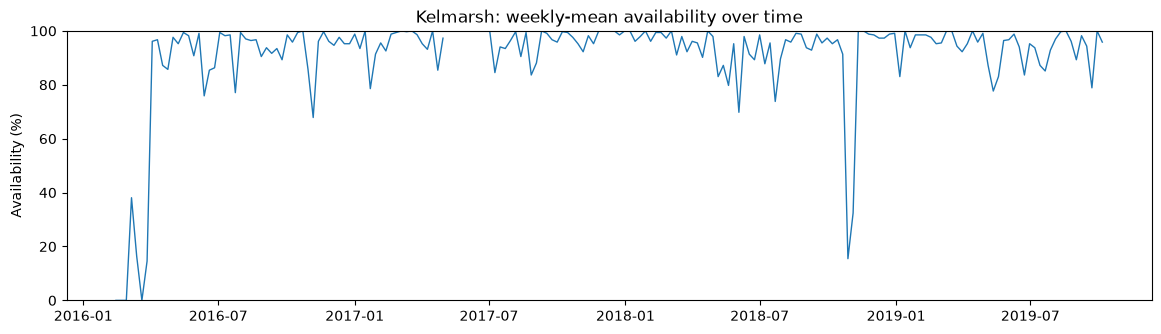

In [7]:
weekly_availability = hourly_availability.resample("W").mean()

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(weekly_availability.index, weekly_availability * 100, linewidth=1)
ax.set_ylabel("Availability (%)")
ax.set_ylim(0, 100)
ax.set_title("Kelmarsh: weekly-mean availability over time")
plt.show()

## Monthly-mean scatter: raw PECD vs. availability-adjusted PECD

Monthly-mean correlation, raw PECD:          0.806  bias=-0.093 MW
Monthly-mean correlation, availability-adj.: 0.959  bias=-0.275 MW


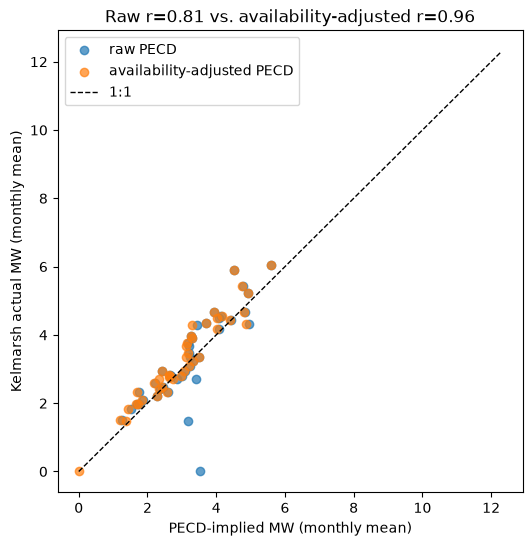

In [8]:
monthly = comparison.resample("MS").mean().dropna()
corr = monthly["kelmarsh_actual_mw"].corr(monthly["pecd_implied_mw"])
bias_mw = (monthly["pecd_implied_mw"] - monthly["kelmarsh_actual_mw"]).mean()
corr_adj = monthly["kelmarsh_actual_mw"].corr(monthly["pecd_implied_mw_availability_adjusted"])
bias_adj_mw = (monthly["pecd_implied_mw_availability_adjusted"] - monthly["kelmarsh_actual_mw"]).mean()
print(f"Monthly-mean correlation, raw PECD:          {corr:.3f}  bias={bias_mw:+.3f} MW")
print(f"Monthly-mean correlation, availability-adj.: {corr_adj:.3f}  bias={bias_adj_mw:+.3f} MW")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(monthly["pecd_implied_mw"], monthly["kelmarsh_actual_mw"], label="raw PECD", alpha=0.7)
ax.scatter(
    monthly["pecd_implied_mw_availability_adjusted"],
    monthly["kelmarsh_actual_mw"],
    label="availability-adjusted PECD",
    alpha=0.7,
)
lims = [0, installed_capacity_mw]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlabel("PECD-implied MW (monthly mean)")
ax.set_ylabel("Kelmarsh actual MW (monthly mean)")
ax.set_title(f"Raw r={corr:.2f} vs. availability-adjusted r={corr_adj:.2f}")
ax.legend()
plt.show()

## Hourly scatter: availability-adjusted PECD vs. actual

The monthly-mean view above averages away a lot of hour-to-hour noise.
This checks the same availability-adjusted PECD series at its native
hourly resolution: correlation, mean absolute error (MAE, in MW), and
normalized MAE (MAE as a percentage of Kelmarsh's own mean hourly
output -- the same `nmae_pct` convention used in this book's
`04_pecd_potential_vs_smard_observed` page).

Hourly correlation:        0.855
Hourly MAE:                1.181 MW
Hourly normalized MAE:     35.8%


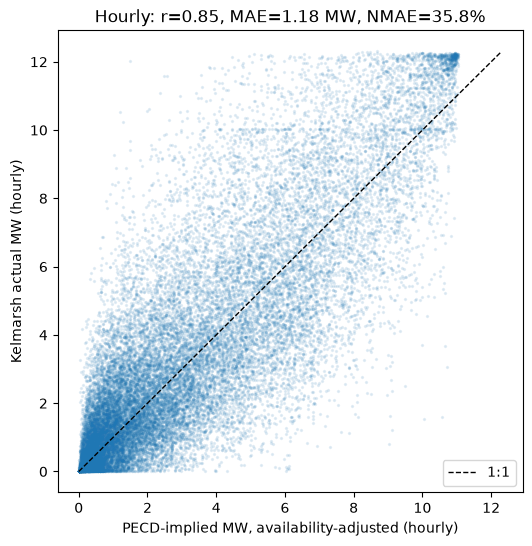

In [9]:
hourly = comparison[["kelmarsh_actual_mw", "pecd_implied_mw_availability_adjusted"]].dropna()

corr_hourly = hourly["kelmarsh_actual_mw"].corr(hourly["pecd_implied_mw_availability_adjusted"])
err_hourly = hourly["pecd_implied_mw_availability_adjusted"] - hourly["kelmarsh_actual_mw"]
mae_hourly = err_hourly.abs().mean()
nmae_hourly_pct = mae_hourly / hourly["kelmarsh_actual_mw"].mean() * 100

print(f"Hourly correlation:        {corr_hourly:.3f}")
print(f"Hourly MAE:                {mae_hourly:.3f} MW")
print(f"Hourly normalized MAE:     {nmae_hourly_pct:.1f}%")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    hourly["pecd_implied_mw_availability_adjusted"],
    hourly["kelmarsh_actual_mw"],
    s=2,
    alpha=0.1,
    rasterized=True,
)
lims = [0, installed_capacity_mw]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlabel("PECD-implied MW, availability-adjusted (hourly)")
ax.set_ylabel("Kelmarsh actual MW (hourly)")
ax.set_title(f"Hourly: r={corr_hourly:.2f}, MAE={mae_hourly:.2f} MW, NMAE={nmae_hourly_pct:.1f}%")
ax.legend()
plt.show()

As expected, the hourly cloud is far noisier than the monthly-mean
scatter above -- individual hours carry real short-term variability
(wind gusts, ramp events, sub-hourly curtailment) that both a monthly
average and the coarse hourly availability correction smooth over.
The correlation and NMAE here are the more honest, harder-to-game
numbers for "how good is this at hourly resolution", as opposed to the
monthly view's more favorable r=0.96.

## Correlation vs. aggregation level

If the hourly scatter isn't a bug, it should be explainable as ordinary
high-frequency noise that gets averaged out at coarser resolutions.
Checked directly by resampling both series to increasingly coarse
windows before computing the correlation.

          raw PECD  availability-adjusted PECD
hourly       0.810                       0.855
3-hourly     0.828                       0.875
6-hourly     0.846                       0.894
daily        0.877                       0.929
weekly       0.871                       0.952
monthly      0.806                       0.959


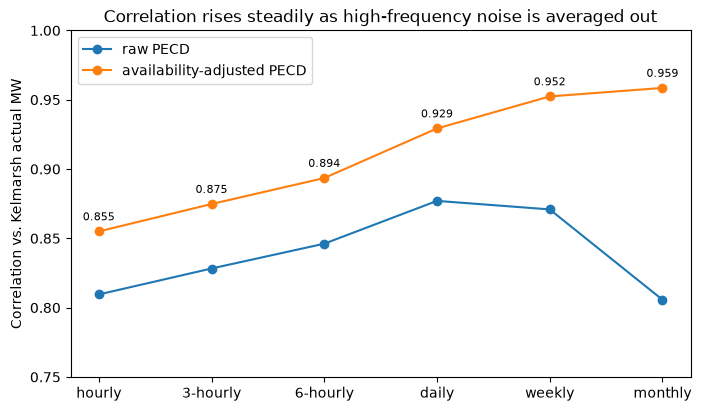

In [10]:
AGGREGATIONS = [
    ("h", "hourly"),
    ("3h", "3-hourly"),
    ("6h", "6-hourly"),
    ("D", "daily"),
    ("W", "weekly"),
    ("MS", "monthly"),
]

agg_labels = [label for _, label in AGGREGATIONS]
corr_raw_by_agg = []
corr_adj_by_agg = []
for freq, _ in AGGREGATIONS:
    r = comparison.resample(freq).mean().dropna()
    corr_raw_by_agg.append(r["kelmarsh_actual_mw"].corr(r["pecd_implied_mw"]))
    corr_adj_by_agg.append(r["kelmarsh_actual_mw"].corr(r["pecd_implied_mw_availability_adjusted"]))

agg_corr = pd.DataFrame(
    {"raw PECD": corr_raw_by_agg, "availability-adjusted PECD": corr_adj_by_agg}, index=agg_labels
)
print(agg_corr.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(agg_corr.index, agg_corr["raw PECD"], marker="o", label="raw PECD")
ax.plot(agg_corr.index, agg_corr["availability-adjusted PECD"], marker="o", label="availability-adjusted PECD")
for x, y in zip(agg_corr.index, agg_corr["availability-adjusted PECD"]):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("Correlation vs. Kelmarsh actual MW")
ax.set_title("Correlation rises steadily as high-frequency noise is averaged out")
ax.legend()
plt.show()

The steady, monotonic climb from hourly (0.86) to monthly (0.96) -- with
no jump or plateau at any particular step -- is exactly what averaging
out uncorrelated high-frequency noise looks like, and is a different
signature than a timestamp/timezone bug would leave (a real
off-by-some-hours error would show up as a step change once the
aggregation window becomes coarser than the offset, not this smooth
gradient). The gap is genuine physical noise -- PECD's single
~28km-scale weather
grid cell is inherently smoother than one real farm's actual
gust-by-gust, wake-affected, occasionally-curtailed output. Confirmed
quantitatively too: the hour-to-hour change in Kelmarsh's actual output
has a standard deviation of 1.08 MW, vs. only 0.43 MW for the
availability-adjusted PECD series, despite both series having a similar
overall level of variation (std of the level itself: 3.27 vs. 2.93 MW).

Note the **raw** PECD line isn't monotonic the same way -- it actually
dips at weekly/monthly. That's not a contradiction: raw PECD's error is
dominated by the two multi-week downtime periods (a *systematic* bias,
not noise), and at monthly resolution there are only 43 data points, so
those few heavily-biased months carry outsized leverage on the
correlation. Averaging helps precisely when the gap is noise, which is
why only the availability-adjusted line climbs cleanly -- once known
downtime is factored out, what's left really is high-frequency weather
noise that a longer averaging window legitimately smooths away.

## Takeaways

- PECD's onshore wind capacity factor for zone UK03, scaled by
  Kelmarsh's installed capacity, already tracks the farm's real metered
  generation well: monthly-mean correlation 0.81, mean bias under a
  tenth of a MW over the full ~5.5-year window.
- Correcting for measured downtime (scaling PECD by the hour's fraction
  of available time) lifts the monthly correlation to 0.96 and removes
  both large monthly outliers almost entirely -- strong evidence that
  Kelmarsh's downtime, not PECD's weather modeling, is the main driver
  of the residual gap.
- The correction does introduce a small systematic downward shift in
  the mean bias (-0.09 -> -0.28 MW): average hourly availability across
  the whole record is ~90%, not 100%, so the adjustment nudges every
  month down a little, not just the two problem months.
- This is a single farm, single technology, single country -- a much
  smaller sample than the national SMARD comparisons elsewhere in this
  book, but a genuine independent check: it validates PECD against
  *plant-level* metered truth rather than a national aggregate.
- The diffuse hourly scatter is genuine high-frequency noise, not a
  timestamp/timezone problem: correlation climbs smoothly and
  monotonically from 0.86 (hourly) to
  0.96 (monthly) as aggregation removes gust-scale variability that a
  single weather-model grid cell was never going to capture for one
  specific farm.